# Edinburgh Airbnb — Exploratory Data Analysis

Runs the plotting/analysis functions defined in `src/eda.py` against the cleaned, enriched data in `data/processed/`. Each section poses the business question being explored, runs the corresponding `eda.py` function (which saves its figure(s) to `output/figures/` and returns a dict of summary stats), and the written interpretation.

In [1]:
import sys
sys.path.append("../src")

from IPython.display import Image, display

from eda import (
    load_data,
    load_calendar,
    plot_price_distribution,
    plot_listings_per_host,
    plot_review_score_distribution,
    plot_host_segment_comparison,
    plot_price_by_neighbourhood,
    plot_geographic_scatter,
    plot_seasonal_price_trend,
)

listing_master = load_data()
calendar_df = load_calendar()

listing_master.shape, calendar_df.shape

((6244, 98), (2284170, 5))

## Price Distributions

**Business question:** What does the nightly price distribution look like across all listings, and does it differ meaningfully by room type and property type?

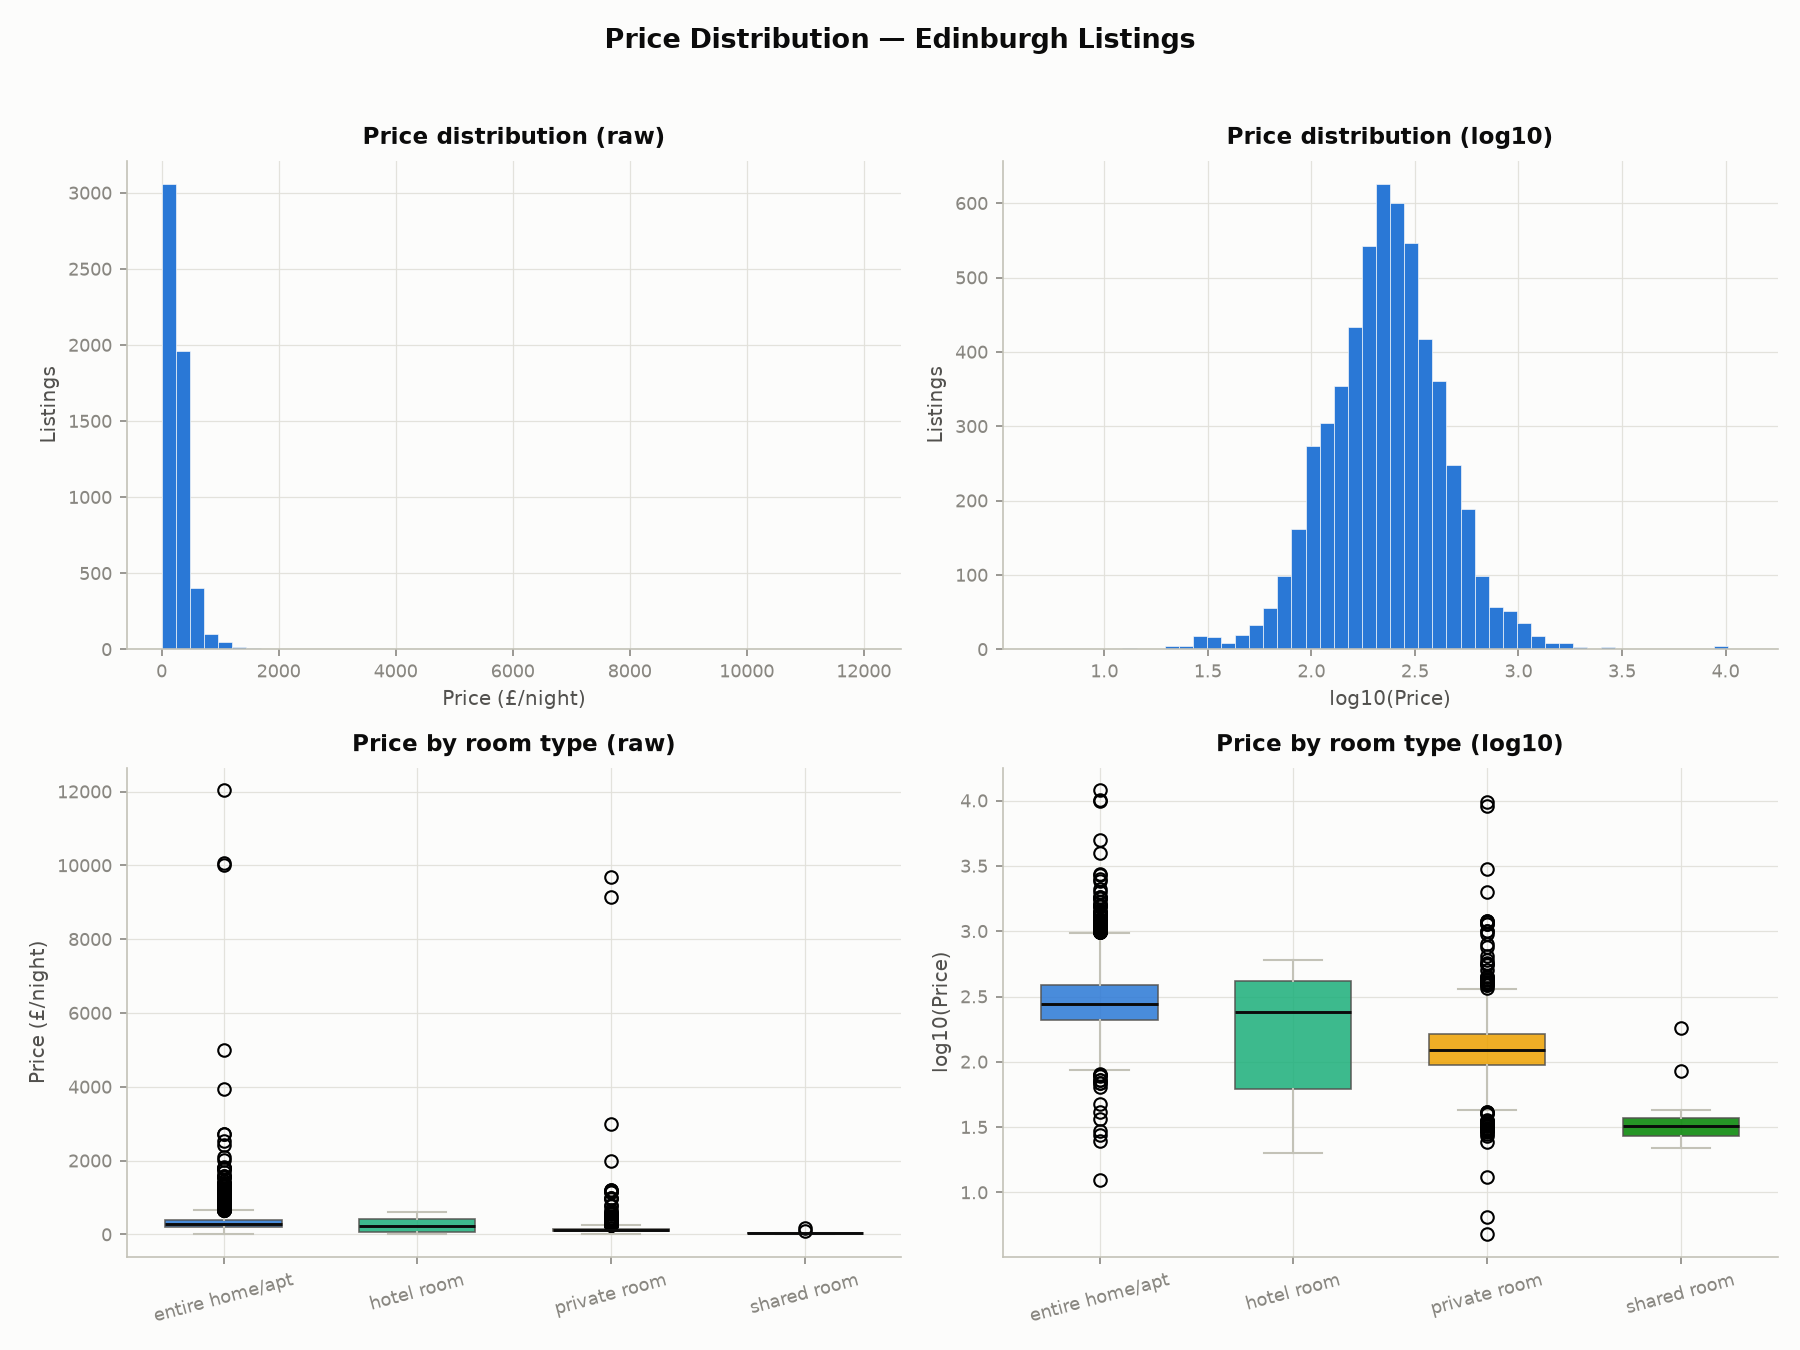

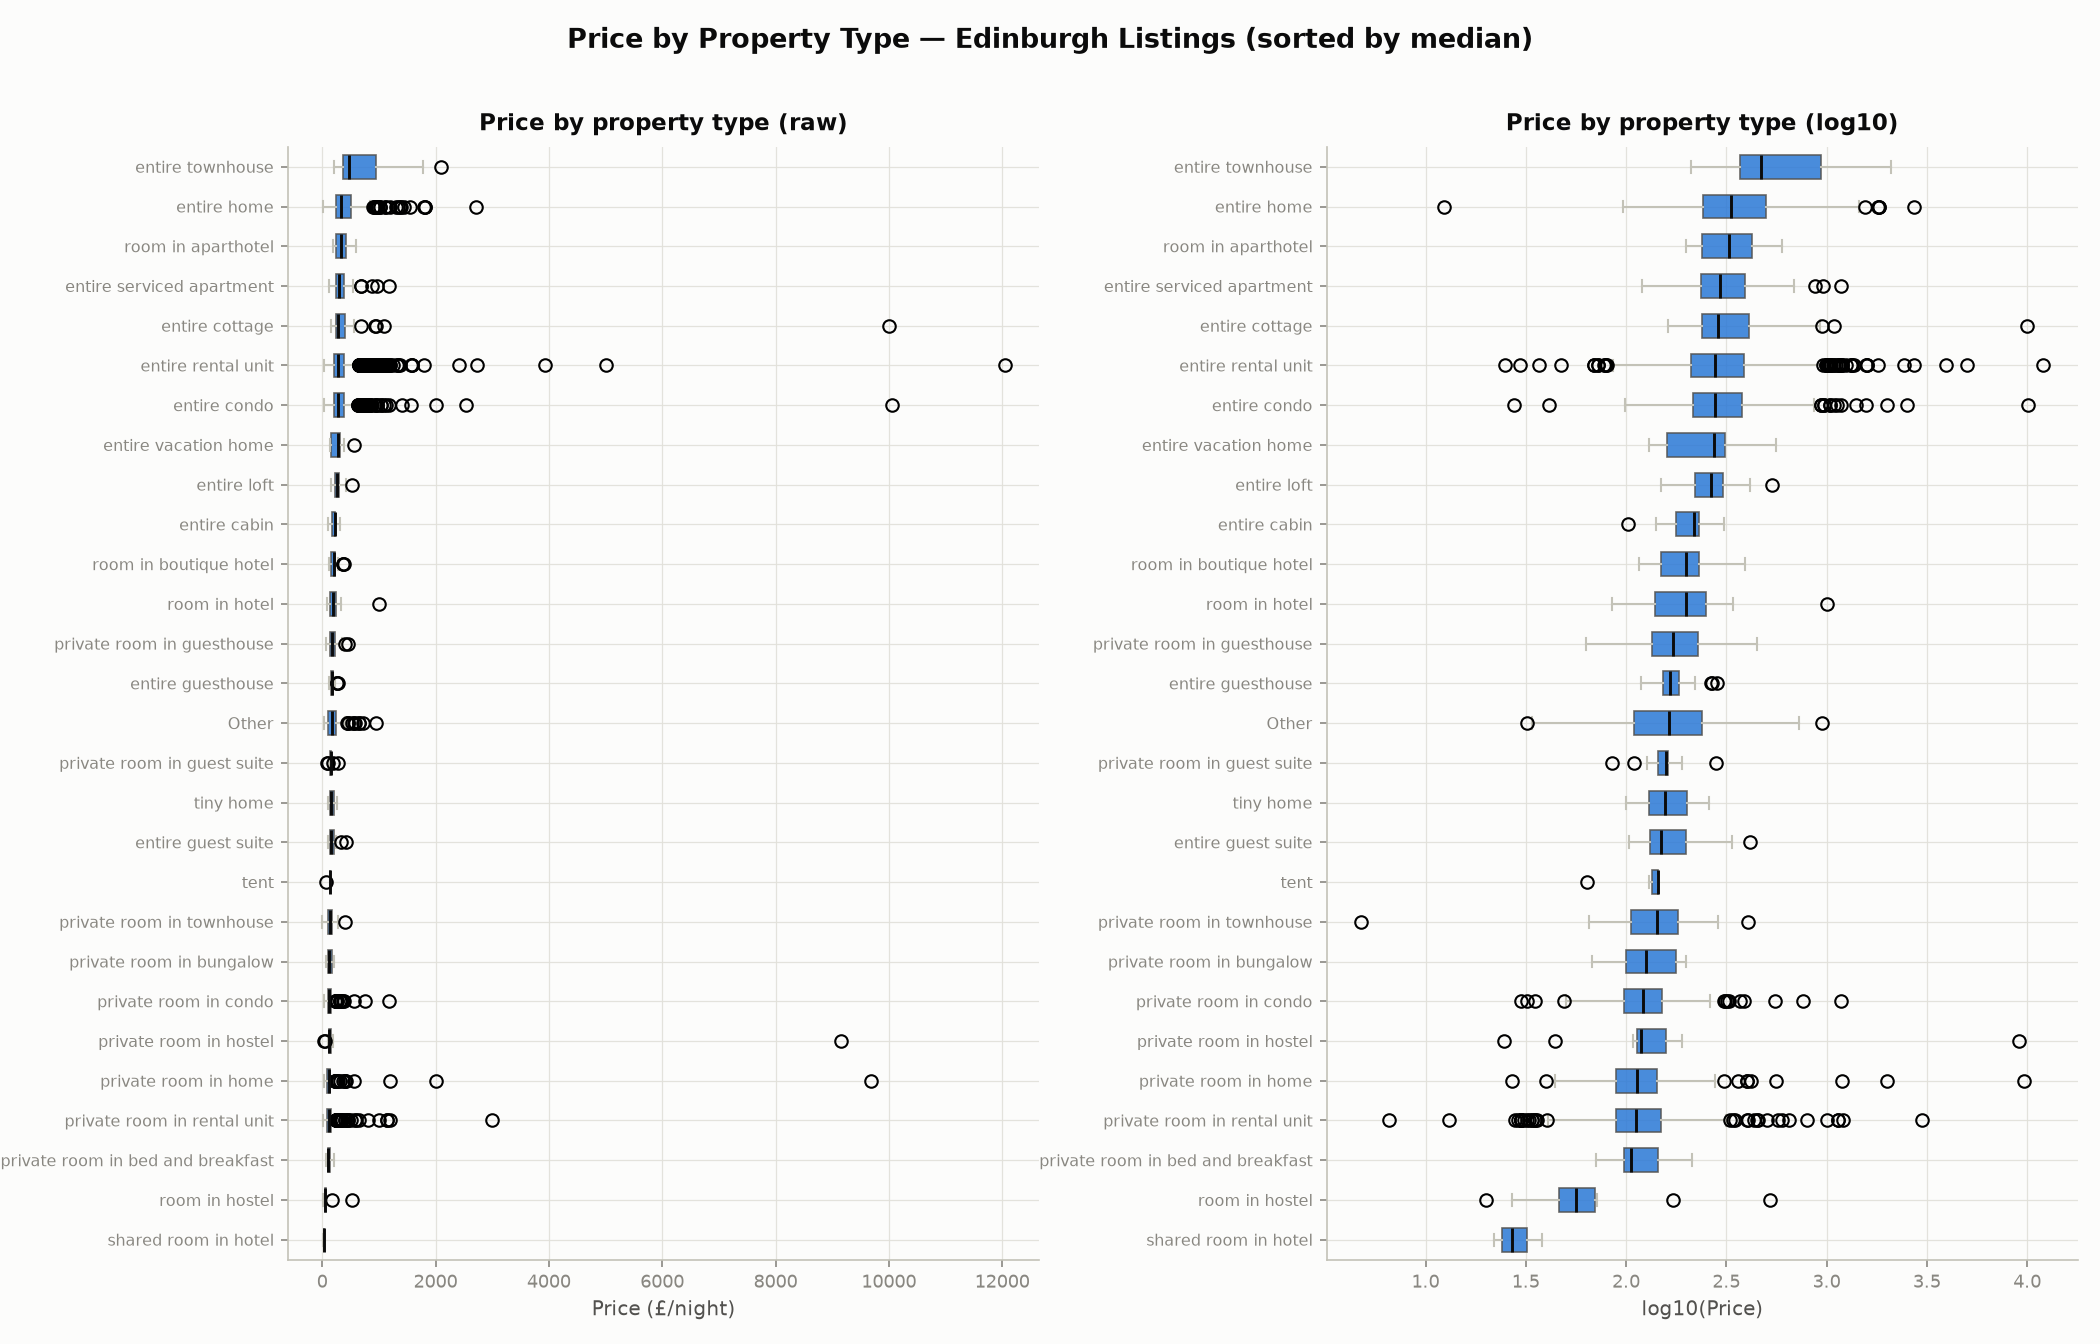

{'price_count': 5610,
 'price_missing_pct': np.float64(10.15),
 'price_mean': np.float64(288.82),
 'price_median': np.float64(230.5),
 'price_std': np.float64(371.86),
 'price_skew': np.float64(18.48),
 'price_p90': np.float64(500.0),
 'median_price_by_room_type': {'entire home/apt': np.float64(279.0),
  'hotel room': np.float64(240.0),
  'private room': np.float64(122.5),
  'shared room': np.float64(32.0)},
 'median_price_top5_property_types': {'entire townhouse': np.float64(473.0),
  'entire home': np.float64(331.83),
  'room in aparthotel': np.float64(327.5),
  'entire serviced apartment': np.float64(293.0),
  'entire cottage': np.float64(287.0)}}

In [2]:
stats = plot_price_distribution(listing_master)
display(Image(filename="../output/figures/price_distribution.png"))
display(Image(filename="../output/figures/price_distribution_by_property_type.png"))
stats

### Interpretation

Most Edinburgh Airbnb listings are priced below £150 per night, while only a small number of luxury listings cost several thousand pounds, with some exceeding £12,000 per night. These extreme outliers make the average (mean) price misleading, so the median is used throughout the analysis as it better represents the typical listing price.

Entire homes and townhouses are generally the most expensive and contain most of the high-priced outliers, whereas private and shared rooms are more affordable and have more consistent prices. In practice, most hosts compete in the £50–150 per night range, while the few ultra-luxury listings represent a separate market and are not suitable benchmarks for typical properties.

## Host Segmentation

**Business question:** How concentrated is the Edinburgh listings market among a small number of hosts?

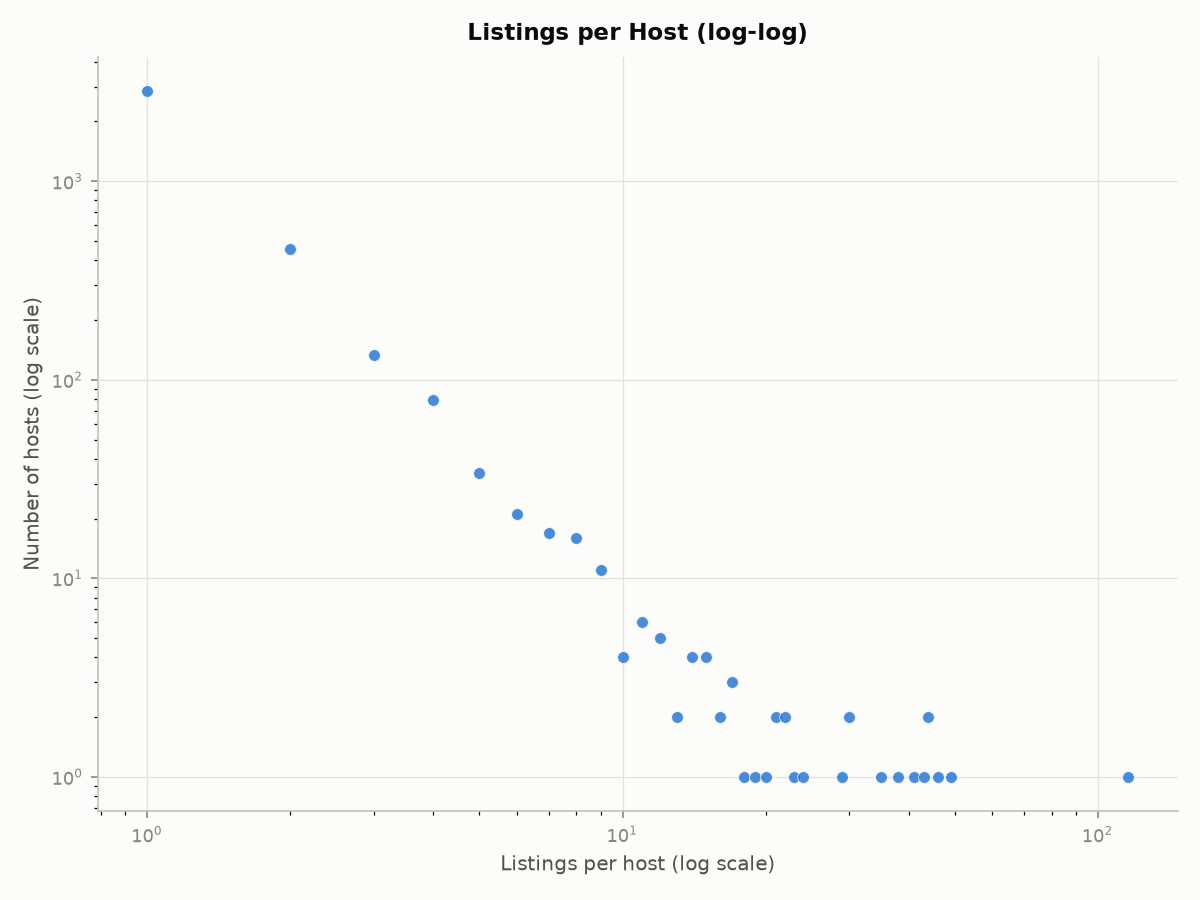

{'n_hosts': 3669,
 'n_listings': 6244,
 'avg_listings_per_host': np.float64(1.7),
 'median_listings_per_host': 1,
 'max_listings_single_host': 116,
 'top_10pct_host_count': 367,
 'top_10pct_listing_share_pct': np.float64(39.93)}

In [3]:
stats = plot_listings_per_host(listing_master)
display(Image(filename="../output/figures/listings_per_host.png"))
stats

### Interpretation

Most Airbnb hosts in Edinburgh have only one listing, but a small number manage many properties. In fact, one host manages around 120 listings, and the top 10% of hosts (367 hosts) collectively own about 40% of all Airbnb listings in the city.

**What this means in practice:** Edinburgh's Airbnb market is not made up only of casual hosts renting out a spare room. A significant share of listings is managed by professional hosts with multiple properties. For businesses offering services such as pricing tools or portfolio management, these multi-property hosts represent a high-value customer segment. Reaching just a few hundred professional hosts provides access to a large portion of the market, making it much more efficient than targeting thousands of individual single-listing hosts.

**Business question:** Are review scores broadly distributed, or is there a sign of rating inflation clustered near the top of the scale?

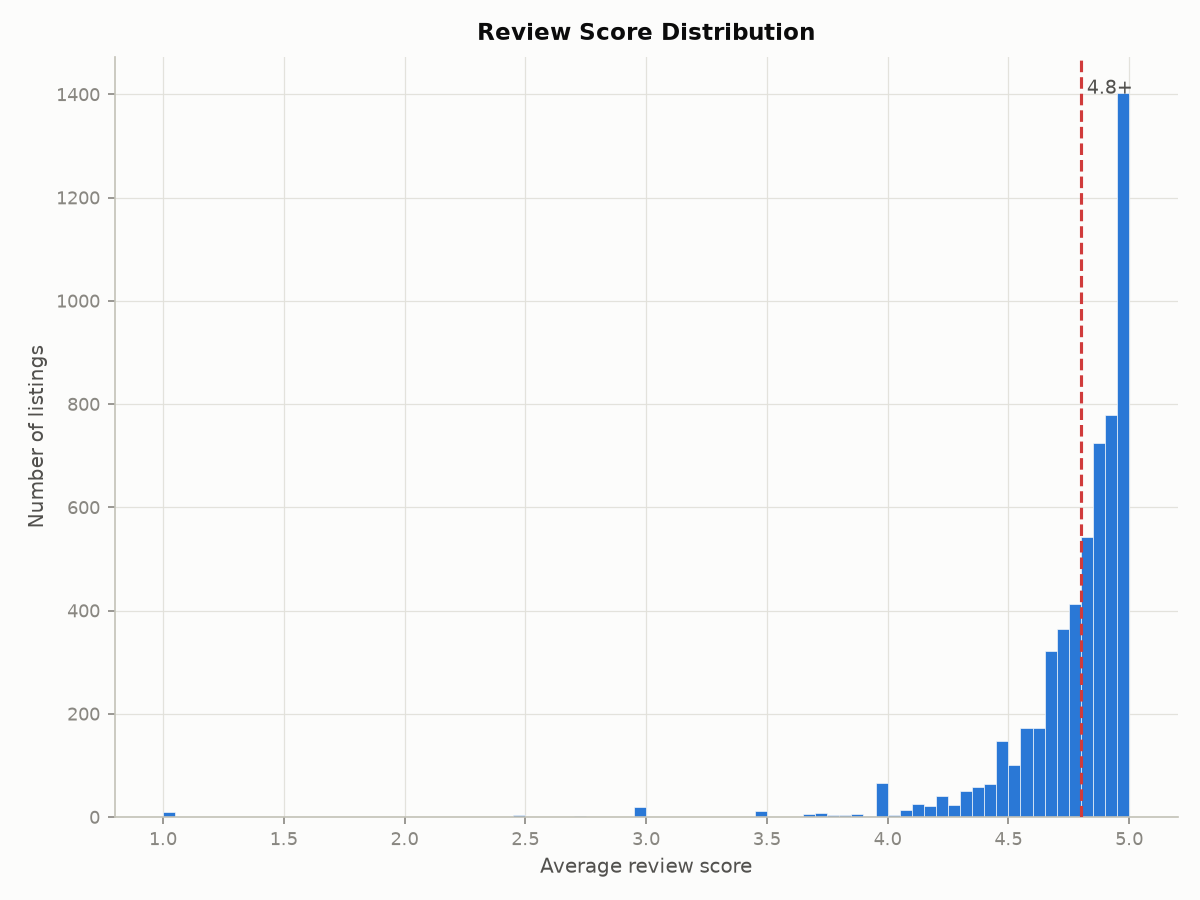

{'reviewed_listing_count': 5583,
 'no_review_score_pct': np.float64(10.59),
 'avg_review_score': np.float64(4.783),
 'median_review_score': np.float64(4.86),
 'pct_scoring_4_8_or_higher': np.float64(64.07)}

In [4]:
stats = plot_review_score_distribution(listing_master)
display(Image(filename="../output/figures/review_score_distribution.png"))
stats

### Interpretation

Nearly all Airbnb listings in Edinburgh have very high review ratings. Around 64% of listings have an average rating of 4.8 or higher, with 5.0 being the most common score. Very few listings are rated below 4.0, and almost none fall below 3.5.

This does not necessarily mean that almost every stay is perfect. Instead, it is likely influenced by rating inflation, where guests who had positive experiences are more likely to leave reviews, while dissatisfied guests often do not. There may also be social pressure for both hosts and guests to leave positive ratings.

**What this means in practice:** Since most listings receive similarly high ratings, the review score alone is not a strong indicator of quality. For platform operators or investors, it is more useful to consider additional factors, such as the number of reviews and how recent those reviews are, to gain a more accurate understanding of a listing's performance and guest satisfaction.

**Business question:** Do single-listing hosts differ from multi-listing hosts, and do superhosts differ from non-superhosts, in price, occupancy, and review score?

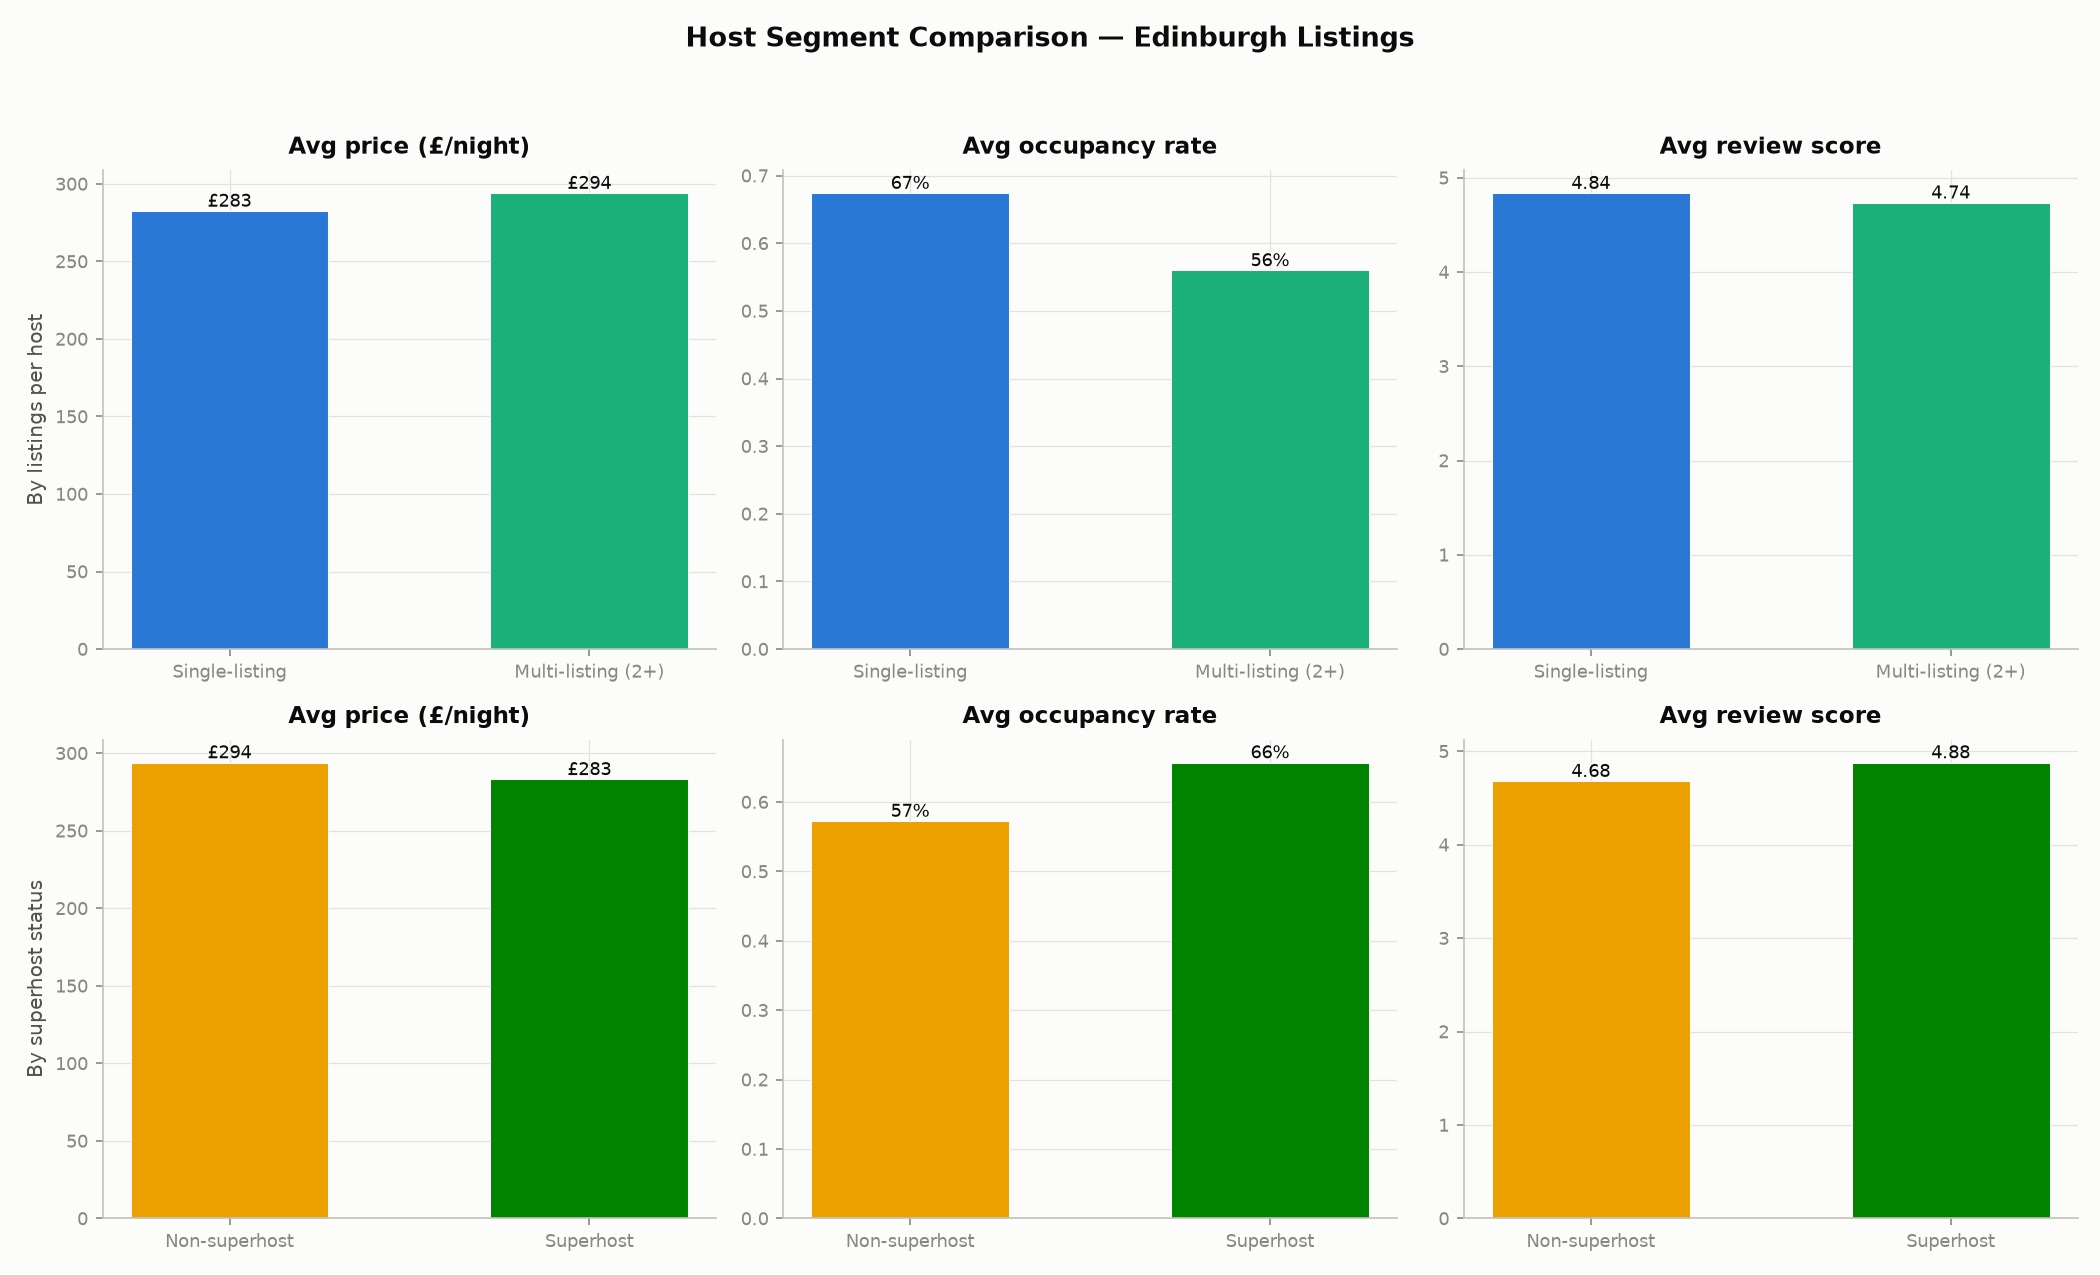

{'n_single_listing_hosts': 2853,
 'n_multi_listing_hosts': 816,
 'n_superhosts': 1818,
 'n_non_superhosts': 1850,
 'by_host_size': {'Single-listing': {'price': 282.549,
   'occupancy_rate_365': 0.674,
   'review_scores_rating': 4.837},
  'Multi-listing (2+)': {'price': 294.038,
   'occupancy_rate_365': 0.56,
   'review_scores_rating': 4.735}},
 'by_superhost_status': {'Non-superhost': {'price': 294.004,
   'occupancy_rate_365': 0.573,
   'review_scores_rating': 4.68},
  'Superhost': {'price': 283.147,
   'occupancy_rate_365': 0.657,
   'review_scores_rating': 4.879}}}

In [5]:
stats = plot_host_segment_comparison(listing_master)
display(Image(filename="../output/figures/host_segment_comparison.png"))
stats

### Interpretation

Two comparisons were made in this analysis: single-listing vs. multi-listing hosts, and Superhosts vs. non-Superhosts.

**Single-listing vs. multi-listing hosts:** Hosts with only one listing perform better than those managing multiple properties. They have higher occupancy (67% vs. 56%) and better average review scores (4.84 vs. 4.74), while charging almost the same nightly price. This suggests that single-listing hosts may provide a more personal experience, leading to greater guest satisfaction.

**Superhost vs. non-Superhost:** Superhosts charge slightly lower prices on average (£283 per night vs. £294), showing that the Superhost badge does not allow hosts to charge a price premium. However, Superhosts achieve higher occupancy (66% vs. 57%) and higher review scores (4.88 vs. 4.68), indicating better overall performance.

**What this means in practice:** For hosts, the results suggest that increasing occupancy and maintaining high guest satisfaction are more effective ways to improve earnings than simply increasing prices. For investors or platform operators, both Superhost status and whether a host manages a single listing or multiple listings are useful indicators of likely occupancy, with Superhosts and single-listing hosts generally achieving better performance than large multi-property hosts without the badge.

## Geographic Pricing

**Business question:** Which neighbourhoods command the highest and lowest median prices?

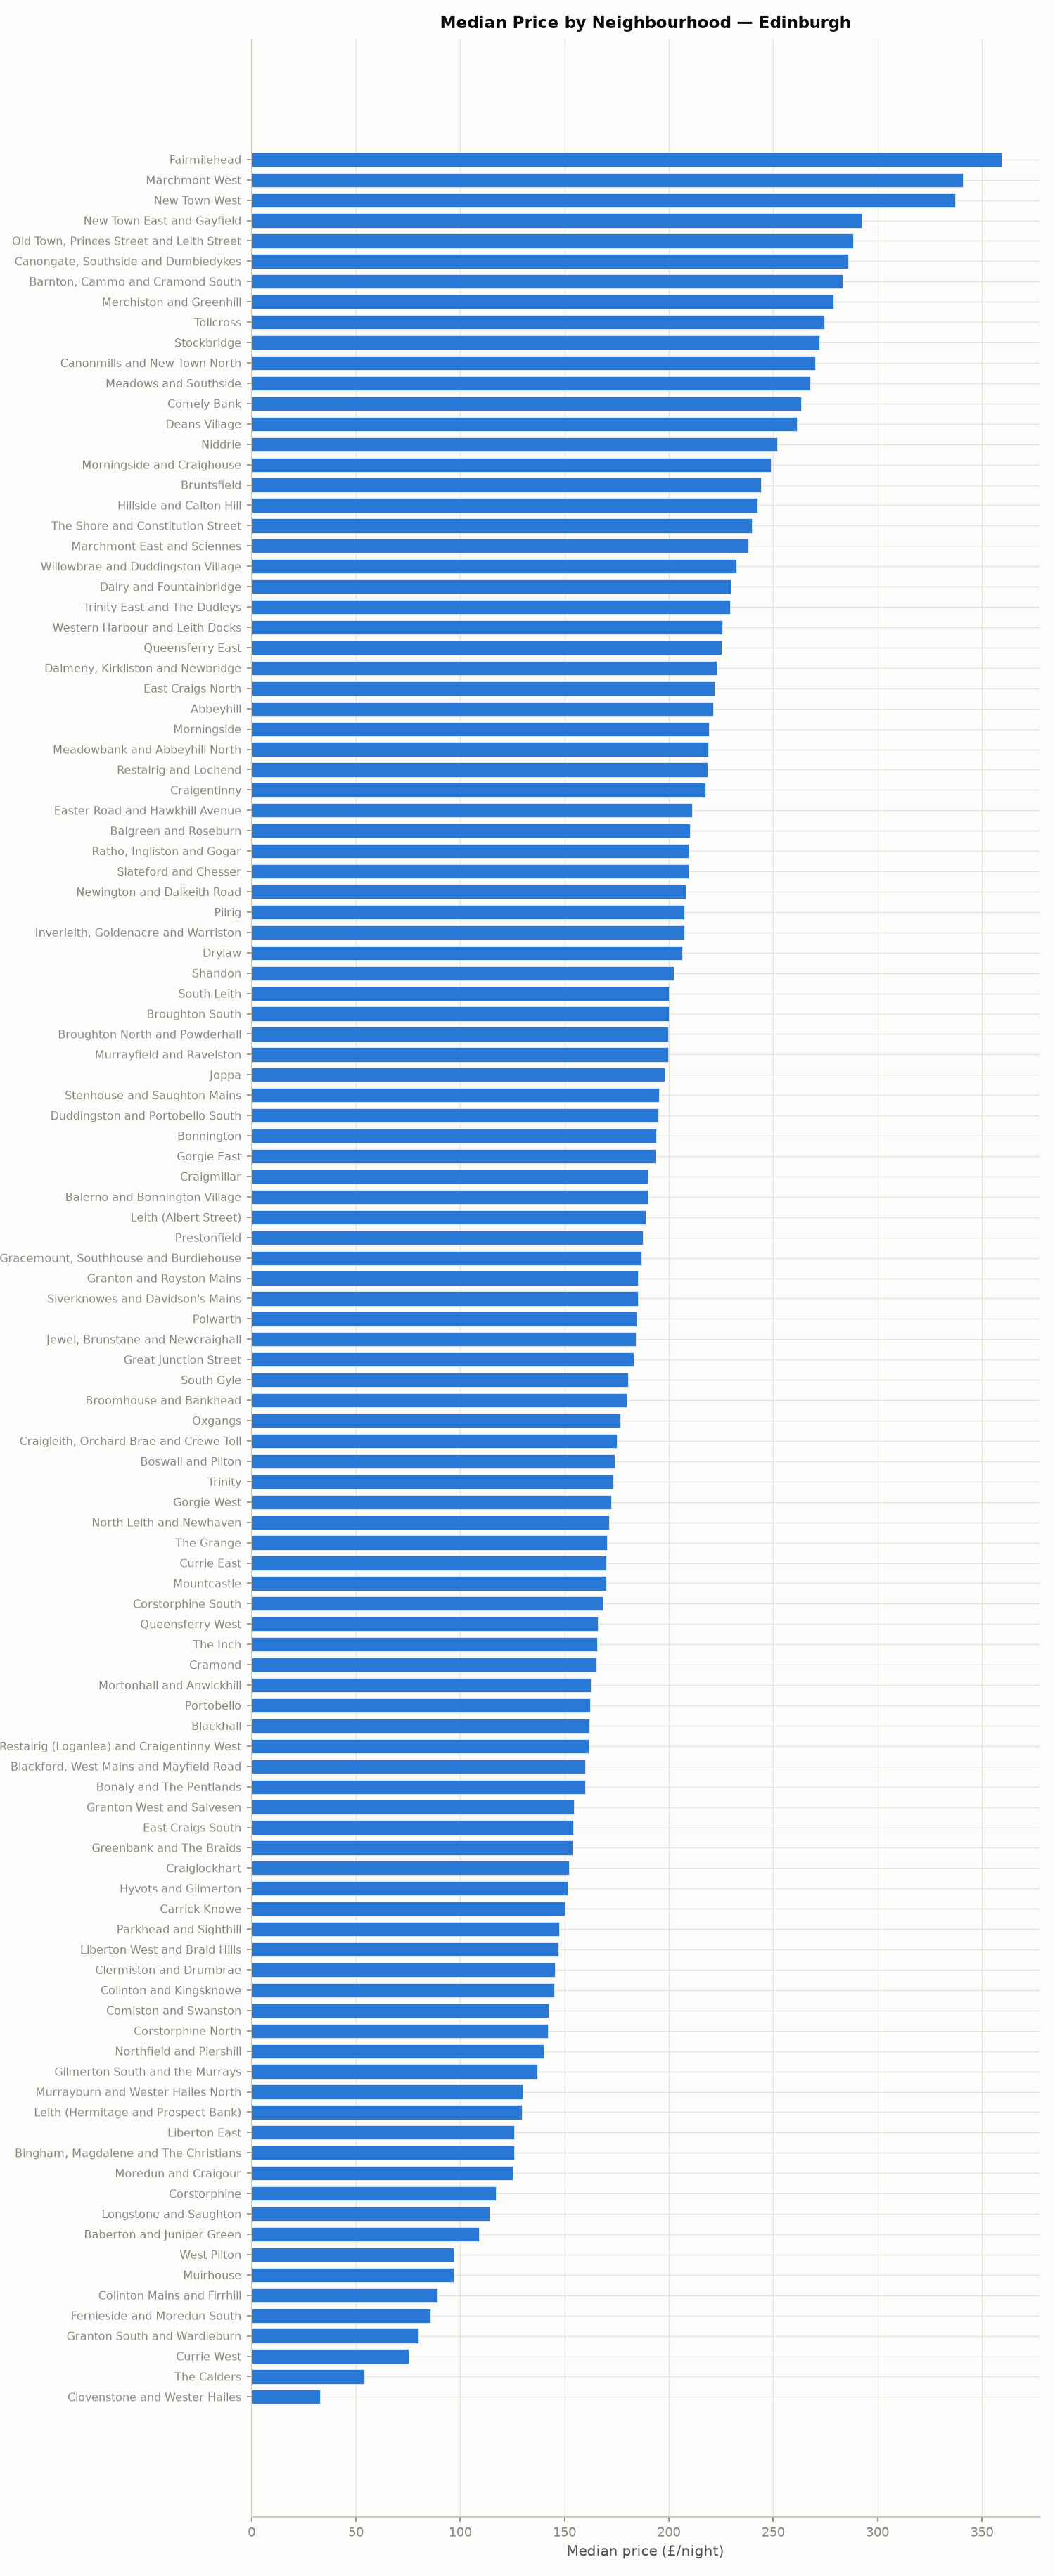

{'n_neighbourhoods': 111,
 'highest_median_price_neighbourhood': 'Fairmilehead',
 'highest_median_price': np.float64(359.5),
 'lowest_median_price_neighbourhood': 'Clovenstone and Wester Hailes',
 'lowest_median_price': np.float64(32.95),
 'citywide_median_price': np.float64(230.5)}

In [6]:
stats = plot_price_by_neighbourhood(listing_master)
display(Image(filename="../output/figures/price_by_neighbourhood.png"))
stats

### Interpretation

A listing's location has a major impact on its price. The most expensive neighbourhood, Fairmilehead, has a typical nightly price of around £360, while the least expensive, Clovenstone and Wester Hailes, has a typical price of about £33. This means the most expensive neighbourhood is roughly 11 times more expensive than the cheapest.

**What this means in practice:** Neighbourhood is one of the most important factors influencing Airbnb prices, along with the type of property. For investors, this means location should be considered a key decision when purchasing or managing properties, as it can have a much greater impact on pricing than many other factors. While this analysis clearly shows that location has a strong influence on price, further analysis would be needed to directly compare its impact with factors such as property type to determine which has the greater overall effect.

**Business question:** Is there a visible spatial gradient in price across the city?

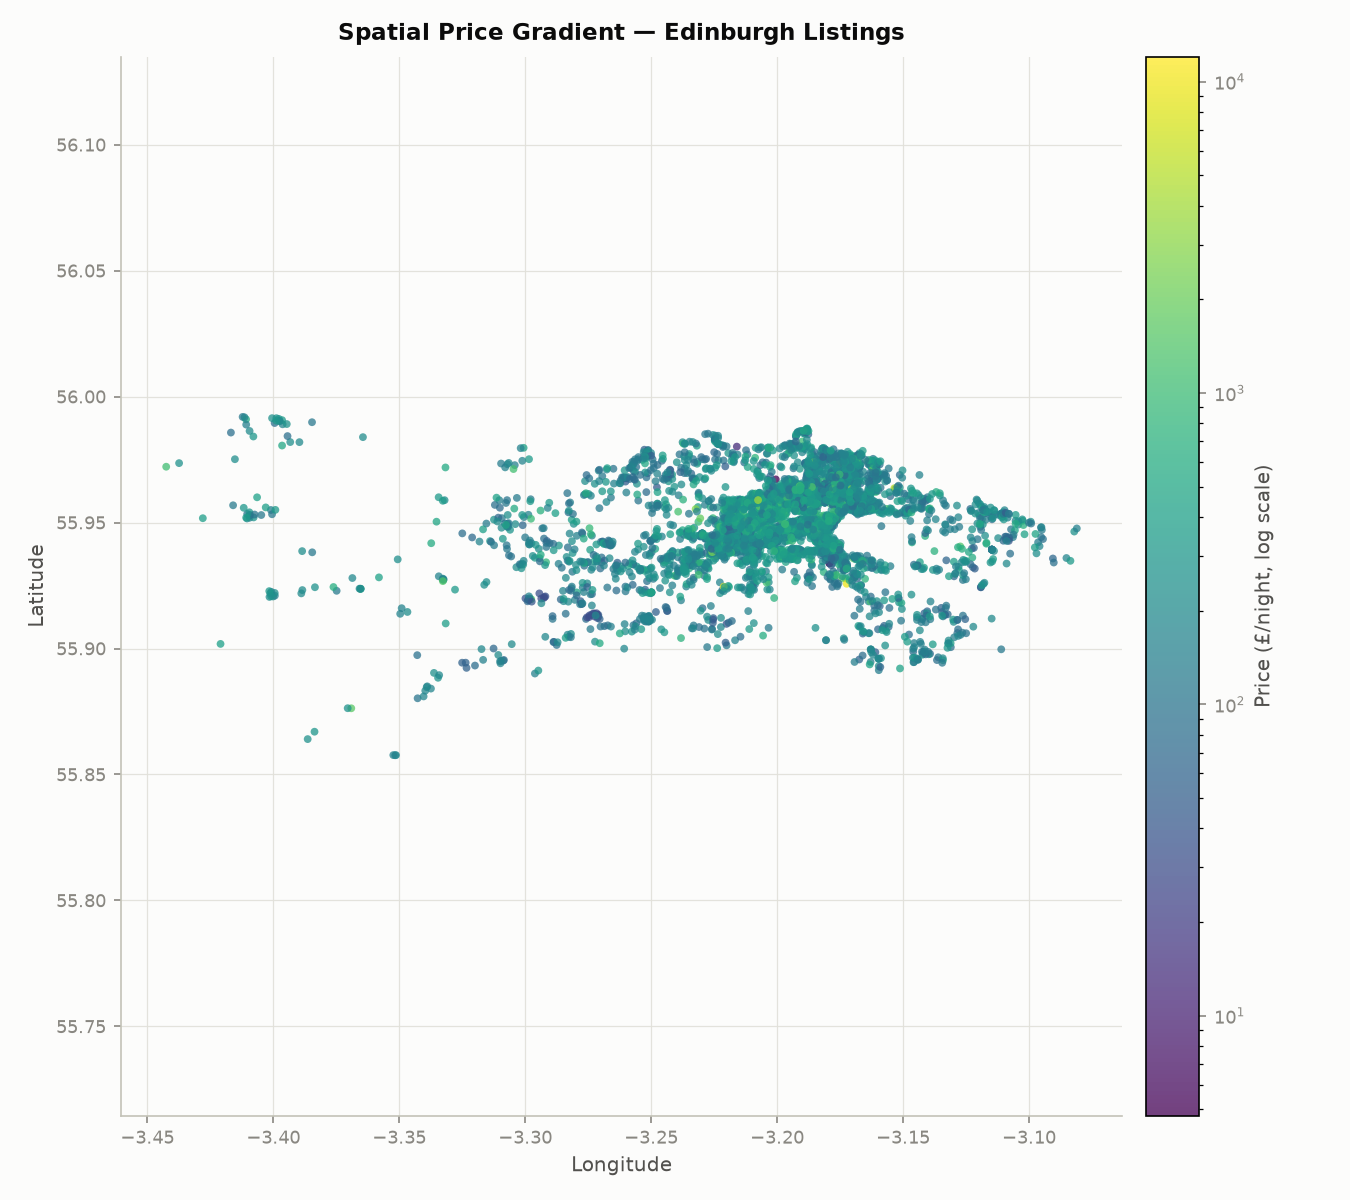

{'n_listings_plotted': 5610,
 'n_listings_missing_coords_or_price': 634,
 'lat_range': (np.float64(55.8576), np.float64(55.992)),
 'lon_range': (np.float64(-3.4425), np.float64(-3.081))}

In [7]:
stats = plot_geographic_scatter(listing_master)
display(Image(filename="../output/figures/geographic_price_scatter.png"))
stats

### Interpretation

This map shows the exact location of every Airbnb listing, with yellow representing higher-priced listings and purple representing lower-priced listings. Two clear patterns can be seen. First, most listings are concentrated in Edinburgh's city centre, while the outer areas have far fewer listings. Second, prices are fairly mixed across the map, with most listings appearing in similar green/teal shades and only a few very expensive or very cheap listings scattered throughout. This means there is no clear pattern of "expensive city centre and cheap outskirts."

**What this means in practice:** The map is more useful for showing where Airbnb listings are concentrated than for explaining price differences across locations. The neighbourhood-level price analysis provides a more reliable picture of how prices vary because it summarizes prices within each area rather than showing individual listings. For platform operators, the high concentration of listings in the city centre highlights where the market is most active, making it valuable for decisions such as targeted marketing and resource allocation.

## Seasonal Trend

**Business question:** Does average price vary by month across the calendar year, and when is the peak?

In [8]:
stats = plot_seasonal_price_trend(calendar_df)
if stats.get("status") == "ok":
    display(Image(filename="../output/figures/seasonal_price_trend.png"))
stats

plot_seasonal_price_trend: calendar data has no 'price' column -- no figure generated.


{'status': 'unavailable',
 'reason': 'calendar.csv has no price column in this extract'}

### Interpretation

This question could not be answered using the available dataset. Although the calendar data shows whether a listing was available or unavailable on each day, it does not include the daily price. As a result, it is not possible to analyze how Airbnb prices change from month to month throughout the year.

This is a limitation of the dataset itself rather than an error in the data processing. Similar missing information was also found in other fields, such as host_since, indicating that this is a characteristic of the dataset rather than a one-time issue.

**What this means in practice:** We cannot identify the best times of the year for hosts to increase or decrease their prices because the historical pricing data is unavailable. To perform this type of analysis in the future, a newer dataset containing calendar-level pricing would need to be collected, either from Inside Airbnb or directly from Airbnb over time.

## Hypothesis Testing

Formal statistical tests (`src/stats_tests.py`) for three of the patterns raised by the EDA above: does room type actually move price, does superhost status actually move review score, and does price actually vary by neighbourhood.

In [9]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

from stats_tests import run_two_group_test, run_anova

### H1: Price by Room Type (Entire home/apt vs. Private room)

**Null hypothesis (H0):** There is no difference in nightly price between 'Entire home/apt' and 'Private room' listings.

**Alternative hypothesis (Ha):** Nightly price differs between 'Entire home/apt' and 'Private room' listings.

In [10]:
h1_result = run_two_group_test(listing_master, "room_type", "price", "entire home/apt", "private room")
print(h1_result["summary"])

'entire home/apt' listings have significantly higher price than 'private room' (Mann-Whitney U, p<0.001), with a large effect size (rank-biserial correlation=0.81), meaning this is both a statistically real and practically substantial difference. Bootstrap 95% CI for the difference in medians (entire home/apt minus private room): [150.90, 163.00].


### Interpretation

**Test used:** The Mann–Whitney U test was used because Airbnb prices are highly skewed and do not follow a normal distribution, making this test more appropriate than a standard t-test.

**Result:** Entire-home listings are significantly more expensive than private rooms (p < 0.001), with a large difference between the two groups. On average, entire homes cost around £151–£163 more per night than private rooms.

**What this means in practice:** This is a meaningful difference, not just a statistically significant one. For hosts, renting out an entire property can generate much higher nightly prices than renting a private room. For investors, entire-home listings have greater revenue potential per listing, although they may also involve higher costs and management responsibilities.

### H2: Average Review Score by Superhost Status

**Null hypothesis (H0):** There is no difference in average review score between superhosts and non-superhosts.

**Alternative hypothesis (Ha):** Average review score differs between superhosts and non-superhosts.

In [11]:
h2_result = run_two_group_test(listing_master, "host_is_superhost", "review_scores_rating", "t", "f")
print(h2_result["summary"])

't' listings have significantly higher review_scores_rating than 'f' (Mann-Whitney U, p<0.001), with a medium effect size (rank-biserial correlation=0.38), meaning this is both a statistically real and practically substantial difference. Bootstrap 95% CI for the difference in medians (t minus f): [0.14, 0.16].


### Interpretation

**Test used:** The Mann–Whitney U test was used because review scores are clustered near the top of the 5-point scale and are not normally distributed, making this test more suitable than a standard t-test.

**Result:** Superhosts have significantly higher review scores than non-Superhosts (p < 0.001). Although the difference is statistically significant, the average gap is relatively small—around 0.14–0.16 points on a 5-point scale.

**What this means in practice:** Superhost status is a genuine indicator of better guest satisfaction, even though the difference in ratings is modest. For hosts, working towards Superhost status is worthwhile because, as shown earlier, it is also associated with higher occupancy, which has a greater impact on revenue than the small increase in review scores alone.

### H4: Price by Neighbourhood (ANOVA)

**Null hypothesis (H0):** Mean nightly price is the same across all neighbourhoods.

**Alternative hypothesis (Ha):** Mean nightly price differs across at least one neighbourhood.

In [12]:
h4_result = run_anova(listing_master, "neighbourhood_cleansed", "price")
print(h4_result["summary"])

D:\SCHOOL_CAREER\PROJECTS\airbnb-data-engineering\venv\Lib\site-packages\scipy\integrate\_quadpack_py.py:1286: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


price differs significantly across neighbourhood_cleansed groups (one-way ANOVA, p<0.001), with a small effect size (eta-squared=0.039). 'Morningside and Craighouse' has the highest average price (793.56) and 'Clovenstone and Wester Hailes' has the lowest (50.46). Tukey HSD post-hoc found 81 significant pairwise differences across 111 groups; the most extreme is Clovenstone and Wester Hailes vs Morningside and Craighouse (mean diff=743.10, p-adj=0.000). See the returned 'tukey_hsd' table for the full pairwise comparison.


### Interpretation

**Test used:** A one-way ANOVA was used to compare prices across all 111 neighbourhoods, followed by Tukey's HSD test to identify which specific neighbourhoods had significant price differences.

**Result:** Airbnb prices vary significantly between neighbourhoods (p < 0.001). The highest average price was in Morningside and Craighouse (£793.56), while the lowest was in Clovenstone and Wester Hailes (£50.46). However, the effect size was small (eta-squared = 0.039), meaning neighbourhood explains only about 3.9% of the overall variation in prices.

**What this means in practice:** Location does influence Airbnb prices, and some neighbourhoods have much higher prices than others. However, neighbourhood alone is not the main factor affecting price across the entire market. Other factors, such as property type, size, and amenities, are likely to have a greater overall impact on pricing.